# Classical diagnostics for critical temperature estimate for Ising Model

Goal: build a clean classical playground (Ising) and compare a small number of *unsupervised* geometric diagnostics across a temperature grid `T` and system sizes `L`.

**Models**

- 2D Ising (benchmark)

**Pipeline**

1. **Simulation code**: generate equilibrium ensembles over `T` and `L`.
2. **Representations**: raw spins → (optional) block-averaged spins.
3. **Methods**:
   - Diffusion maps on configuration data (density-normalized kernels).
   - Kernel + clustering (Gaussian kernel + k-means; Calinski–Harabasz index).
   - Intrinsic dimension vs `T` (TWO estimators: kNN-MLE and TwoNN).
4. **Unsupervised transition finder (Ising)**: pool configurations across `T`, run diffusion maps + k-means (k=2), then plot the ordered-cluster fraction vs `T` and extract a pseudo-`T_c` (e.g. 50% crossing / max slope).


# Stage I: Symmetry-invariant diffusion maps

This notebook is a clean, reproducible walkthrough of the Stage I pipeline for the 2D Ising model.
The core idea is to build a diffusion-map embedding using a *symmetry-invariant* distance so that
configurations related by the global Z2 flip (all spins -> -all spins) are treated as identical.

Pipeline summary:
1. Generate or load equilibrium configurations on a temperature grid.
2. Build a diffusion kernel using the median-distance heuristic for epsilon.
3. Compute diffusion coordinates and perform k-means clustering.
4. Extract an unsupervised transition curve (ordered-cluster fraction vs T).
5. Add spectral and intrinsic-dimension diagnostics as sanity checks.

All steps below are organized into small, labeled cells that can be run top-to-bottom.


In [69]:
# Imports (avoid pandas / sklearn to stay robust on mixed envs)
import math
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh

# Paths
CWD = Path.cwd()
ISING_DIR = CWD if (CWD / "ising.cpp").exists() else (CWD / "Ising")
CACHE_DIR = ISING_DIR / "stage1_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(7)





## Simulation utilities
Metropolis sweeps and basic observables are included for completeness and quick checks.

These helpers are used only if new data are generated; cached datasets can be used directly.


In [70]:
# --- Simulation utilities ---

def ising_energy_density(spins: np.ndarray, J: float = 1.0) -> float:
    # Count each bond once (+x, +y).
    e = -J * (
        np.sum(spins * np.roll(spins, -1, axis=0))
        + np.sum(spins * np.roll(spins, -1, axis=1))
    )
    return float(e / spins.size)


_CHECKERBOARD_MASKS: dict[int, tuple[np.ndarray, np.ndarray]] = {}


def _checkerboard_masks(L: int) -> tuple[np.ndarray, np.ndarray]:
    masks = _CHECKERBOARD_MASKS.get(L)
    if masks is not None:
        return masks
    ii, jj = np.indices((L, L))
    m0 = ((ii + jj) % 2) == 0
    masks = (m0, ~m0)
    _CHECKERBOARD_MASKS[L] = masks
    return masks


def ising_sweep(spins: np.ndarray, beta: float, rng: np.random.Generator, J: float = 1.0) -> None:
    """One Metropolis sweep using checkerboard updates (vectorized)."""

    L = spins.shape[0]
    m0, m1 = _checkerboard_masks(L)
    for mask in (m0, m1):
        nn = (
            np.roll(spins, 1, axis=0)
            + np.roll(spins, -1, axis=0)
            + np.roll(spins, 1, axis=1)
            + np.roll(spins, -1, axis=1)
        )
        dE = 2.0 * J * spins * nn
        u = rng.random(spins.shape)
        accept = (dE <= 0.0) | (u < np.exp(-beta * dE))
        flips = mask & accept
        spins[flips] *= -1


def block_average_ising(spins: np.ndarray, block: int = 2) -> np.ndarray:
    L = spins.shape[0]
    if L % block != 0:
        raise ValueError("L must be divisible by block")
    return spins.reshape(L // block, block, L // block, block).mean(axis=(1, 3))


## Geometry and diffusion maps
We use a Z2-invariant squared distance for Ising configurations:

  d^2(x, y) = ||x||^2 + ||y||^2 - 2|x · y|

This identifies x and -x as the same point and removes the trivial global symmetry.
The diffusion kernel uses the median of pairwise distances as the epsilon heuristic.


In [71]:
# --- Geometry / diagnostics utilities ---

def pairwise_distances(X: np.ndarray) -> np.ndarray:
    """Symmetry-invariant squared distances for Ising (Z2 quotient)."""

    X = np.asarray(X, dtype=np.float32)
    n = int(X.shape[0])
    if n == 0:
        return np.empty((0, 0), dtype=float)

    gram = X @ X.T
    norms = np.sum(X * X, axis=1, dtype=np.float32)
    D2 = norms[:, None] + norms[None, :] - 2.0 * np.abs(gram)
    np.fill_diagonal(D2, 0.0)
    return D2

def diffusion_map_eigs(
    X: np.ndarray,
    n_eigs: int = 6,
    alpha: float = 1.0,
    epsilon: float | None = None,
    knn: int | None = None,
):
    """Density-normalized diffusion maps eigenpairs.

    Returns eigenvalues and *right* eigenvectors of the Markov matrix P.
    If `knn` is provided, builds a sparse kNN kernel (recommended for N > ~1500).
    """

    n = int(X.shape[0])
    if n == 0:
        return np.array([], dtype=float), np.empty((0, 0), dtype=float)

    if n == 1:
        return np.array([1.0], dtype=float), np.ones((1, 1), dtype=float)

    k = None if knn is None else int(knn)
    if k is not None:
        k = min(k, n - 1)
        if k < 1:
            k = None

    # Dense kernel: good for small N.
    if k is None or k >= n - 1 or n < 1500:
        D2 = pairwise_distances(X)
        if epsilon is None:
            vals = D2[D2 > 0]
            eps = float(np.median(vals)) if vals.size else 1.0
            epsilon = eps if eps > 0 else 1.0

        K = np.exp(-D2 / epsilon)
        q = K.sum(axis=1)
        q_alpha = np.power(q, alpha)
        q_alpha[q_alpha == 0] = 1.0
        K_tilde = K / (q_alpha[:, None] * q_alpha[None, :])

        d = K_tilde.sum(axis=1)
        d[d == 0] = 1.0
        S = K_tilde / np.sqrt(d[:, None] * d[None, :])

        evals, evecs = np.linalg.eigh(S)
        order = np.argsort(evals)[::-1]
        evals = evals[order][: min(n_eigs, n)]
        evecs = evecs[:, order][:, : evals.size]
        psi = evecs / np.sqrt(d)[:, None]
        return evals, psi

    # Sparse kNN kernel (built from the same symmetry-invariant distances).
    idx, d2 = knn_graph(X, k=k)
    return diffusion_map_eigs_from_knn_graph(
        idx,
        d2,
        n_eigs=n_eigs,
        alpha=alpha,
        epsilon=epsilon,
    )


def kmeans_numpy(
    X: np.ndarray,
    k: int,
    rng: np.random.Generator,
    n_init: int = 10,
    max_iter: int = 200,
):
    best_inertia = None
    best_labels = None
    best_centers = None

    n = X.shape[0]
    for _ in range(n_init):
        centers = X[rng.choice(n, size=k, replace=False)].copy()
        labels = np.zeros(n, dtype=int)

        for _it in range(max_iter):
            d2 = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
            new_labels = np.argmin(d2, axis=1)
            if np.array_equal(new_labels, labels) and _it > 0:
                break
            labels = new_labels

            for j in range(k):
                mask = labels == j
                if not np.any(mask):
                    centers[j] = X[int(rng.integers(0, n))]
                else:
                    centers[j] = X[mask].mean(axis=0)

        inertia = float(((X - centers[labels]) ** 2).sum())
        if best_inertia is None or inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels.copy()
            best_centers = centers.copy()

    return best_labels, best_centers, float(best_inertia)


def _knn_distances(X: np.ndarray, k: int) -> np.ndarray:
    """Return distances to the 1..k nearest neighbors (Z2-invariant)."""

    n = X.shape[0]
    if n <= k:
        return np.empty((0, k), dtype=float)

    D2 = pairwise_distances(X)
    idx = np.argpartition(D2, kth=k, axis=1)[:, : k + 1]
    dists = np.empty((n, k), dtype=float)
    for i in range(n):
        cand = idx[i]
        cand = cand[cand != i]
        cand = cand[:k]
        order = np.argsort(D2[i, cand])
        nn = cand[order]
        dists[i] = np.sqrt(D2[i, nn])
    return dists


def intrinsic_dim_two_nn(X: np.ndarray) -> float:
    """TwoNN intrinsic-dimension estimator (Facco et al.)."""

    dists = _knn_distances(X, k=2)
    if dists.size == 0:
        return float("nan")

    r1 = dists[:, 0]
    r2 = dists[:, 1]
    mask = (r1 > 0) & np.isfinite(r1) & np.isfinite(r2)
    mu = (r2[mask] / r1[mask])
    mu = mu[mu > 1.0]
    if mu.size < 10:
        return float("nan")

    mu = np.sort(mu)
    n = mu.size
    F = (np.arange(1, n + 1) - 0.5) / n
    x = np.log(mu)
    y = -np.log(1.0 - F)
    slope, _intercept = np.polyfit(x, y, 1)
    return float(slope)


def intrinsic_dim_knn_mle(X: np.ndarray, k: int = 10) -> float:
    """Levina–Bickel kNN MLE intrinsic-dimension estimator."""

    n = X.shape[0]
    k = min(k, n - 1)
    if k < 3:
        return float("nan")

    dists = _knn_distances(X, k=k)
    if dists.size == 0:
        return float("nan")

    rk = dists[:, k - 1]
    logs = np.log((rk[:, None] + 1e-12) / (dists[:, : k - 1] + 1e-12))
    s = np.sum(logs, axis=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        di = (k - 1) / s

    di = di[np.isfinite(di) & (di > 0)]
    return float(np.median(di)) if di.size else float("nan")

def knn_graph(X: np.ndarray, k: int) -> tuple[np.ndarray, np.ndarray]:
    """Return (indices, squared_distances) for the kNN graph."""

    n = int(X.shape[0])
    k = min(int(k), max(n - 1, 0))
    if k <= 0:
        return np.empty((n, 0), dtype=int), np.empty((n, 0), dtype=float)

    D2 = pairwise_distances(X)
    idx = np.argpartition(D2, kth=k, axis=1)[:, : k + 1]
    knn_idx = np.empty((n, k), dtype=int)
    knn_d2 = np.empty((n, k), dtype=float)
    for i in range(n):
        cand = idx[i]
        cand = cand[cand != i]
        cand = cand[:k]
        order = np.argsort(D2[i, cand])
        nn = cand[order]
        knn_idx[i] = nn
        knn_d2[i] = D2[i, nn]
    return knn_idx, knn_d2

def diffusion_map_eigs_from_knn_graph(
    idx: np.ndarray,
    d2: np.ndarray,
    n_eigs: int = 6,
    alpha: float = 1.0,
    epsilon: float | None = None,
):
    """Diffusion maps eigenpairs from a precomputed kNN graph."""

    n = int(idx.shape[0])
    if n == 0:
        return np.array([], dtype=float), np.empty((0, 0), dtype=float)

    if n == 1:
        return np.array([1.0], dtype=float), np.ones((1, 1), dtype=float)

    k = int(idx.shape[1])
    if k == 0:
        return np.array([1.0], dtype=float), np.ones((n, 1), dtype=float)

    if epsilon is None:
        vals = d2[d2 > 0]
        eps = float(np.median(vals)) if vals.size else 1.0
        epsilon = eps if eps > 0 else 1.0

    W = np.exp(-d2 / float(epsilon))
    rows = np.repeat(np.arange(n), k)
    cols = idx.reshape(-1)
    data = W.reshape(-1)
    K = sp.coo_matrix((data, (rows, cols)), shape=(n, n)).tocsr()
    K = (K + K.T) * 0.5

    q = np.asarray(K.sum(axis=1)).reshape(-1)
    q_alpha = np.power(q, alpha)
    q_alpha[q_alpha == 0] = 1.0
    Dq_inv = sp.diags(1.0 / q_alpha)
    K_tilde = Dq_inv @ K @ Dq_inv

    d = np.asarray(K_tilde.sum(axis=1)).reshape(-1)
    d[d == 0] = 1.0
    D_inv_sqrt = sp.diags(1.0 / np.sqrt(d))
    S = D_inv_sqrt @ K_tilde @ D_inv_sqrt

    k_eigs = min(int(n_eigs), n - 1)
    try:
        evals, evecs = eigsh(S, k=k_eigs, which="LA", tol=1e-6, maxiter=20000)
    except Exception:
        Sd = S.toarray() if sp.issparse(S) else np.asarray(S)
        evals, evecs = np.linalg.eigh(Sd)

    order = np.argsort(evals)[::-1]
    evals = evals[order]
    evecs = evecs[:, order]

    psi = evecs / np.sqrt(d)[:, None]
    return evals, psi





## Dataset generation and caching
Configurations are generated on a temperature grid and cached to disk
under `Ising/stage1_cache` to avoid reruns.


In [72]:
# --- Dataset generation with caching ---

@dataclass
class Dataset:
    temps: np.ndarray
    X: np.ndarray  # shape (n_temps, n_samples, n_features)
    obs: dict       # dict of arrays shape (n_temps, n_samples)
    configs: np.ndarray | None = None  # optional raw configs, shape (n_temps, n_samples, L*L)


def cache_path(
    model: str,
    L: int,
    temps: np.ndarray,
    n_samples: int,
    burn_in: int,
    gap: int,
    seed: int,
    extra: str = "",
) -> Path:
    key = f"{model}_L{L}_nt{len(temps)}_ns{n_samples}_burn{burn_in}_gap{gap}_seed{seed}{extra}.npz"
    return CACHE_DIR / key


def generate_ising_dataset(
    L: int,
    temps: np.ndarray,
    n_samples: int,
    burn_in: int,
    gap: int,
    seed: int = 0,
    block: int | None = None,
    align_z2: bool = True,
) -> Dataset:
    extra_parts = []
    if block:
        extra_parts.append(f"blk{block}")
    if align_z2:
        extra_parts.append("z2")
    extra = "_" + "_".join(extra_parts) if extra_parts else ""

    path = cache_path("ising", L, temps, n_samples, burn_in, gap, seed=seed, extra=extra)
    if path.exists():
        data = np.load(path, allow_pickle=True)
        configs = data["configs"] if "configs" in data else None
        return Dataset(temps=data["temps"], X=data["X"], obs=data["obs"].item(), configs=configs)

    rng = np.random.default_rng(seed)
    X = []
    configs = []
    mags = []
    enes = []

    for T in temps:
        beta = 1.0 / float(T)
        spins = rng.choice([-1, 1], size=(L, L)).astype(np.int8)
        for _ in range(burn_in):
            ising_sweep(spins, beta, rng)

        X_T = []
        configs_T = []
        mags_T = []
        enes_T = []
        for _ in range(n_samples):
            for _ in range(gap):
                ising_sweep(spins, beta, rng)
            snap = spins.copy()
            m = float(snap.mean())
            if align_z2 and m < 0.0:
                snap *= -1
                m = -m
            configs_T.append(snap.reshape(-1).astype(np.int8))
            if block:
                snap_f = block_average_ising(snap, block=block).astype(np.float32).reshape(-1)
            else:
                snap_f = snap.astype(np.float32).reshape(-1)
            X_T.append(snap_f)
            mags_T.append(m)
            enes_T.append(ising_energy_density(snap))

        X.append(np.stack(X_T))
        configs.append(np.stack(configs_T))
        mags.append(np.array(mags_T))
        enes.append(np.array(enes_T))

    X = np.stack(X)
    configs = np.stack(configs)
    obs = {"magnetization": np.stack(mags), "energy_density": np.stack(enes)}
    np.savez_compressed(path, temps=temps, X=X, obs=obs, configs=configs, L=L, block=block, align_z2=align_z2)
    return Dataset(temps=temps, X=X, obs=obs, configs=configs)


def load_ising_configs_bin(path: Path, block: int | None = None) -> Dataset:
    """Load Ising configurations written by `ising.cpp` (binary).

    File format (little-endian):
      - 8 bytes magic: b"ISCFG1\\x00\\x00"
      - int32 lattice_L
      - int32 n_temps
      - int32 n_samples
      - int32 align_z2
      - for each temperature block:
          float32 T
          n_samples records of dtype [('spins', int8, L*L), ('mabs', float32), ('energy', float32)]

    Returns a Dataset with:
      - configs: int8 spins in {-1,+1}
      - X: float32 features (raw or block-averaged)
      - obs: {'magnetization': mabs, 'energy_density': energy}
    """

    import struct

    path = Path(path)
    with path.open('rb') as f:
        magic = f.read(8)
        if not magic.startswith(b'ISCFG1'):
            raise ValueError(f"Unexpected magic {magic!r} in {path}")

        lattice_L, n_temps, n_samples, align_z2 = struct.unpack('<4i', f.read(16))
        n_temps = int(n_temps)
        n_samples = int(n_samples)
        size = int(lattice_L) * int(lattice_L)

        temps = np.empty(n_temps, dtype=np.float32)
        configs = np.empty((n_temps, n_samples, size), dtype=np.int8)
        mabs = np.empty((n_temps, n_samples), dtype=np.float32)
        energy = np.empty((n_temps, n_samples), dtype=np.float32)

        rec_dtype = np.dtype([
            ('spins', np.int8, size),
            ('mabs', np.float32),
            ('energy', np.float32),
        ])

        for ti in range(n_temps):
            t_bytes = f.read(4)
            if len(t_bytes) != 4:
                raise EOFError(f"Unexpected EOF while reading temperature header (ti={ti})")
            temps[ti] = struct.unpack('<f', t_bytes)[0]

            rec = np.fromfile(f, dtype=rec_dtype, count=n_samples)
            if rec.size != n_samples:
                raise EOFError(f"Unexpected EOF while reading records for T={temps[ti]}")
            configs[ti] = rec['spins']
            mabs[ti] = rec['mabs']
            energy[ti] = rec['energy']

    # Sort by temperature (the C++ generator often writes descending).
    order = np.argsort(temps)
    temps = temps[order]
    configs = configs[order]
    mabs = mabs[order]
    energy = energy[order]

    X = configs.astype(np.float32)
    if block is not None:
        block = int(block)
        if lattice_L % block != 0:
            raise ValueError(f"L={lattice_L} must be divisible by block={block}")
        Lb = lattice_L // block
        X = X.reshape(n_temps, n_samples, lattice_L, lattice_L)
        X = X.reshape(n_temps, n_samples, Lb, block, Lb, block).mean(axis=(3, 5))
        X = X.reshape(n_temps, n_samples, -1)

    obs = {
        'magnetization': mabs,
        'energy_density': energy,
        '_align_z2': bool(align_z2),
    }
    return Dataset(temps=temps.astype(float), X=X.astype(np.float32), obs=obs, configs=configs)



## Run the Stage I experiment
This cell loads (or generates) datasets and prepares them for analysis.


In [73]:
# --- Run Stage I experiment (generate configs; cached to disk) ---

# If True, load configurations produced by `ising.cpp` (e.g. L=100, 100 samples/temp).
USE_CPP_ISING_CONFIGS = False
CPP_ISING_CONFIG_FILE = ISING_DIR / "ising_configs_L100.bin"

SIZES = [32]  # lattice linear size L

# Ising temperature grid (denser near Tc ~ 2.269).
ISING_TEMPS = np.unique(np.concatenate([
    np.linspace(1.5, 3.2, 18),
    np.linspace(2.0, 2.6, 25),
]))
ISING_SAMPLES_PER_TEMP = 60
ISING_BURN_IN_SWEEPS = 200
ISING_GAP_SWEEPS = 10

# Representation: set BLOCK=2/4 to reduce dimensionality before diffusion maps.
BLOCK = 4


ising_results = {}
if USE_CPP_ISING_CONFIGS:
    if not CPP_ISING_CONFIG_FILE.exists():
        raise FileNotFoundError(
            f"Missing {CPP_ISING_CONFIG_FILE}. Run `g++ -O2 -std=c++17 ising.cpp -o ising && ./ising` in the Ising folder first."
        )
    ising_ds = load_ising_configs_bin(CPP_ISING_CONFIG_FILE, block=BLOCK)
    L_cpp = int(round(np.sqrt(ising_ds.configs.shape[-1]))) if ising_ds.configs is not None else None
    if L_cpp is None:
        raise ValueError('Loaded dataset has no configs; expected raw spins in the binary file.')
    ising_results[L_cpp] = ising_ds
else:
    for L in SIZES:
        ising_ds = generate_ising_dataset(
            L,
            ISING_TEMPS,
            n_samples=ISING_SAMPLES_PER_TEMP,
            burn_in=ISING_BURN_IN_SWEEPS,
            gap=ISING_GAP_SWEEPS,
            seed=7,
            block=BLOCK,
        )

        ising_results[L] = ising_ds


print("Done. Cached under:", CACHE_DIR)



Done. Cached under: /Users/neel/Documents/Github/Classifying-BLK-Transitions/Ising/stage1_cache


## Core results: embedding and ordered fraction
The diffusion-map embedding is plotted and clustered.
The ordered-cluster fraction vs T provides an unsupervised transition curve.


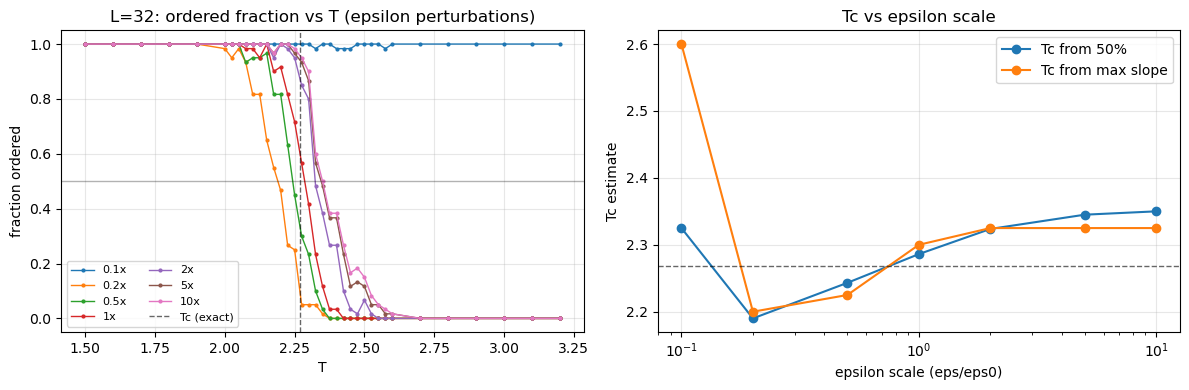

Computed unsupervised Ising transition diagnostics for L: [32]


In [74]:

# --- Unsupervised phase detection (diffusion maps + clustering) ---

# This cell uses a common diffusion-maps heuristic for the kernel scale:
#   epsilon = median(kNN squared distances)
# and then *perturbs* epsilon by a multiplicative factor to assess sensitivity.


def _flatten_dataset(ds: Dataset) -> tuple[np.ndarray, np.ndarray, dict]:
    n_t = int(ds.temps.size)
    n_s = int(ds.X.shape[1])
    T = np.repeat(ds.temps, n_s)
    X = ds.X.reshape(n_t * n_s, -1)

    # Only keep per-sample observables (shape (n_t, n_s)); ignore metadata scalars like '_align_z2'.
    obs = {}
    for k, v in ds.obs.items():
        a = np.asarray(v)
        if a.ndim == 0:
            continue
        if a.size != n_t * n_s:
            continue
        obs[k] = a.reshape(n_t * n_s)

    return T, X, obs


def _crossing_temperature(temps: np.ndarray, values: np.ndarray, target: float = 0.5) -> float:
    temps = np.asarray(temps, dtype=float)
    values = np.asarray(values, dtype=float)
    if temps.size == 0 or values.size == 0:
        return float("nan")

    order = np.argsort(temps)
    temps = temps[order]
    values = values[order]
    y = values - float(target)

    finite = np.isfinite(y)
    if int(np.sum(finite)) < 2:
        return float("nan")

    temps = temps[finite]
    values = values[finite]
    y = values - float(target)

    for i in range(y.size - 1):
        if y[i] == 0.0:
            return float(temps[i])
        if y[i] * y[i + 1] < 0.0:
            t0, t1 = float(temps[i]), float(temps[i + 1])
            v0, v1 = float(values[i]), float(values[i + 1])
            if v1 == v0:
                return float(0.5 * (t0 + t1))
            return t0 + (target - v0) * (t1 - t0) / (v1 - v0)

    idx = int(np.nanargmin(np.abs(y)))
    return float(temps[idx])


ising_unsup: dict[int, dict] = {}

# Diffusion map params
DM_N_EIGS = 6
DM_ALPHA = 1.0
DM_KNN = 50  # neighbors in kNN kernel

# Clustering params
CLUSTER_DIMS = 2  # use (psi2, psi3) for clustering

# Epsilon perturbation: epsilon = eps0 * scale
EPS_SCALES = np.array([0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0], dtype=float)

for L, ds in ising_results.items():
    T_all, X_all, obs_all = _flatten_dataset(ds)
    n_t = int(ds.temps.size)
    n_s = int(ds.X.shape[1])

    # Build kNN graph once (Euclidean distances in the chosen feature space).
    idx_full, d2_full = knn_graph(X_all, k=DM_KNN)
    vals_full = d2_full[d2_full > 0]
    eps0_full = float(np.median(vals_full)) if vals_full.size else 1.0
    eps0_full = eps0_full if eps0_full > 0 else 1.0

    per_scale = {}

    for scale in EPS_SCALES:
        eps = float(eps0_full * float(scale))
        evals, psi = diffusion_map_eigs_from_knn_graph(
            idx_full,
            d2_full,
            n_eigs=DM_N_EIGS,
            alpha=DM_ALPHA,
            epsilon=eps,
        )

        dims = max(1, min(CLUSTER_DIMS, int(psi.shape[1] - 1)))
        Y = psi[:, 1 : 1 + dims] * evals[1 : 1 + dims]

        labels, _centers, _inertia = kmeans_numpy(
            Y,
            k=2,
            rng=np.random.default_rng(123 + int(L) + int(scale * 1000)),
            n_init=20,
            max_iter=300,
        )

        # Orient labels using temperature (ordered phase dominates at the lowest T).
        temps_sorted = np.sort(ds.temps)
        lowT = float(temps_sorted[0])
        mask_low = np.isclose(T_all, lowT)
        f0_low = float(np.mean(labels[mask_low] == 0)) if np.any(mask_low) else float('nan')
        f1_low = float(np.mean(labels[mask_low] == 1)) if np.any(mask_low) else float('nan')
        ordered_cluster = 0 if f0_low >= f1_low else 1
        ordered = labels == ordered_cluster

        temps = np.asarray(ds.temps, dtype=float)
        frac_ordered = np.array(
            [np.mean(ordered[i * n_s : (i + 1) * n_s]) for i in range(temps.size)],
            dtype=float,
        )

        tc_50 = _crossing_temperature(temps, frac_ordered, target=0.5)
        slope = np.gradient(frac_ordered, temps)
        tc_slope = float(temps[int(np.nanargmax(np.abs(slope)))]) if np.any(np.isfinite(slope)) else float('nan')

        per_scale[float(scale)] = {
            "epsilon": float(eps),
            "evals": evals,
            "psi": psi,
            "Y": Y,
            "ordered": ordered,
            "frac_ordered": frac_ordered,
            "Tc_frac50": float(tc_50),
            "Tc_maxslope": float(tc_slope),
        }

    # Choose a default scale=1.0 result for downstream cells.
    base = per_scale.get(1.0, per_scale[float(EPS_SCALES[np.argmin(np.abs(EPS_SCALES - 1.0))])])
    ising_unsup[int(L)] = {
        "temps": np.asarray(ds.temps, dtype=float),
        "T_all": np.asarray(T_all, dtype=float),
        "epsilon_base": float(eps0_full),
        "epsilon_scale": 1.0,
        "epsilon": float(base["epsilon"]),
        "evals": base["evals"],
        "psi": base["psi"],
        "Y": base["Y"],
        "ordered": base["ordered"],
        "frac_ordered": base["frac_ordered"],
        "Tc_frac50": base["Tc_frac50"],
        "Tc_maxslope": base["Tc_maxslope"],
        "per_scale": per_scale,
    }

    # ---- Sensitivity plots (per L) ----
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # (1) ordered-fraction curves for different epsilon scales
    for scale in EPS_SCALES:
        r = per_scale[float(scale)]
        axes[0].plot(ds.temps, r['frac_ordered'], marker='o', ms=2, lw=1, label=f"{scale:g}x")
    axes[0].axhline(0.5, color='k', lw=1, alpha=0.3)
    axes[0].axvline(2.269, color='k', ls='--', lw=1, alpha=0.6, label='Tc (exact)')
    axes[0].set_title(f"L={L}: ordered fraction vs T (epsilon perturbations)")
    axes[0].set_xlabel("T")
    axes[0].set_ylabel("fraction ordered")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(ncol=2, fontsize=8)

    # (2) Tc estimates vs epsilon scale
    tc50 = np.array([per_scale[float(s)]['Tc_frac50'] for s in EPS_SCALES], dtype=float)
    tcs = np.array([per_scale[float(s)]['Tc_maxslope'] for s in EPS_SCALES], dtype=float)
    axes[1].plot(EPS_SCALES, tc50, marker='o', label='Tc from 50%')
    axes[1].plot(EPS_SCALES, tcs, marker='o', label='Tc from max slope')
    axes[1].axhline(2.269, color='k', ls='--', lw=1, alpha=0.6)
    axes[1].set_xscale('log')
    axes[1].set_xlabel('epsilon scale (eps/eps0)')
    axes[1].set_ylabel('Tc estimate')
    axes[1].set_title('Tc vs epsilon scale')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='best')

    plt.tight_layout()
    plt.show()

print('Computed unsupervised Ising transition diagnostics for L:', sorted(ising_unsup))


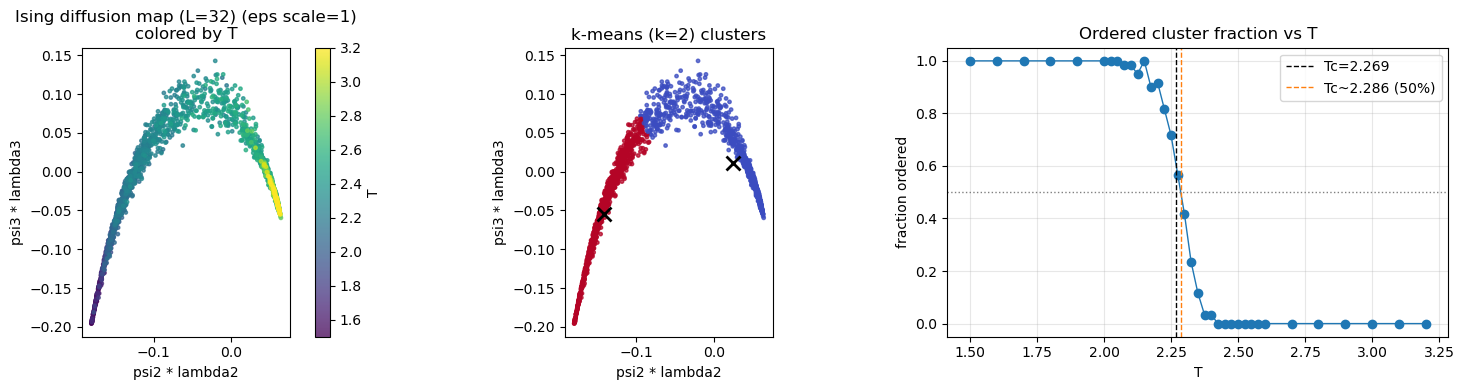

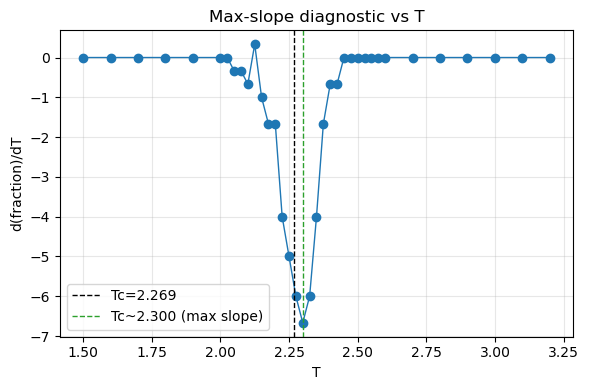

L=32: Tc~2.286 (frac=0.5), Tc~2.300 (max slope)


In [75]:
# --- Visualize embedding + cluster fraction ---

KNOWN_TC = 2.269185314

for L, res in ising_unsup.items():
    temps = res['temps']
    frac = res['frac_ordered']
    Y = res['Y']
    T_all = res['T_all']
    ordered = res['ordered']
    tc50 = float(res['Tc_frac50'])
    tcslope = float(res['Tc_maxslope'])
    eps_scale = res.get('epsilon_scale', None)

    y1 = Y[:, 1] if Y.shape[1] > 1 else np.zeros(Y.shape[0], dtype=float)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    title_eps = f" (eps scale={eps_scale:g})" if eps_scale is not None else ""

    sc0 = axes[0].scatter(Y[:, 0], y1, c=T_all, s=6, alpha=0.75, cmap='viridis')
    axes[0].set_title(f"Ising diffusion map (L={L}){title_eps}\ncolored by T")
    axes[0].set_xlabel('psi2 * lambda2')
    axes[0].set_ylabel('psi3 * lambda3')
    axes[0].set_aspect('equal', adjustable='box')
    fig.colorbar(sc0, ax=axes[0], label='T')

    # Plot cluster labels + cluster centers
    labels = ordered.astype(int)
    axes[1].scatter(Y[:, 0], y1, c=labels, s=6, alpha=0.75, cmap='coolwarm')
    c0 = np.mean(np.stack([Y[~ordered, 0], y1[~ordered]], axis=1), axis=0) if np.any(~ordered) else None
    c1 = np.mean(np.stack([Y[ordered, 0], y1[ordered]], axis=1), axis=0) if np.any(ordered) else None
    if c0 is not None:
        axes[1].plot(c0[0], c0[1], marker='x', ms=10, mew=2, color='k')
    if c1 is not None:
        axes[1].plot(c1[0], c1[1], marker='x', ms=10, mew=2, color='k')

    axes[1].set_title('k-means (k=2) clusters')
    axes[1].set_xlabel('psi2 * lambda2')
    axes[1].set_ylabel('psi3 * lambda3')
    axes[1].set_aspect('equal', adjustable='box')

    axes[2].plot(temps, frac, marker='o', lw=1)
    axes[2].axhline(0.5, color='gray', ls=':', lw=1)
    axes[2].axvline(KNOWN_TC, color='k', ls='--', lw=1, label=f'Tc={KNOWN_TC:.3f}')
    axes[2].axvline(tc50, color='C1', ls='--', lw=1, label=f'Tc~{tc50:.3f} (50%)')
    axes[2].set_title('Ordered cluster fraction vs T')
    axes[2].set_xlabel('T')
    axes[2].set_ylabel('fraction ordered')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(loc='best')

    plt.tight_layout()
    plt.show()

    slope = np.gradient(frac, temps)

    fig2, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.plot(temps, slope, marker='o', lw=1)
    ax.axvline(KNOWN_TC, color='k', ls='--', lw=1, label=f'Tc={KNOWN_TC:.3f}')
    ax.axvline(tcslope, color='C2', ls='--', lw=1, label=f'Tc~{tcslope:.3f} (max slope)')
    ax.set_title('Max-slope diagnostic vs T')
    ax.set_xlabel('T')
    ax.set_ylabel('d(fraction)/dT')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

    plt.tight_layout()
    plt.show()

    print(f'L={L}: Tc~{tc50:.3f} (frac=0.5), Tc~{tcslope:.3f} (max slope)')


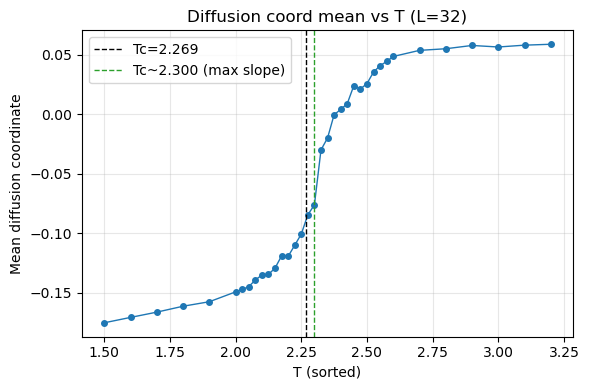

In [76]:
# --- Diffusion coordinate mean vs temperature ---
for L, res in ising_unsup.items():
    temps = res['temps']
    T_all = res['T_all']
    Y = res['Y']
    if Y.shape[1] == 0:
        continue
    coord = Y[:, 0]
    mean_coord = np.array([coord[np.isclose(T_all, float(t))].mean() for t in temps])

    order = np.argsort(temps)
    t_sorted = temps[order]
    m_sorted = mean_coord[order]

    tcslope = float(res.get('Tc_maxslope', float('nan')))

    plt.figure(figsize=(6, 4))
    plt.plot(t_sorted, m_sorted, marker='o', lw=1, markersize=4)
    plt.axvline(KNOWN_TC, color='k', ls='--', lw=1, label=f'Tc={KNOWN_TC:.3f}')
    if np.isfinite(tcslope):
        plt.axvline(tcslope, color='C2', ls='--', lw=1, label=f'Tc~{tcslope:.3f} (max slope)')
    plt.title(f'Diffusion coord mean vs T (L={L})')
    plt.xlabel('T (sorted)')
    plt.ylabel('Mean diffusion coordinate')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()




## Spectral and intrinsic-dimension diagnostics
These diagnostics provide complementary checks on how the random-walk geometry
changes across temperature.


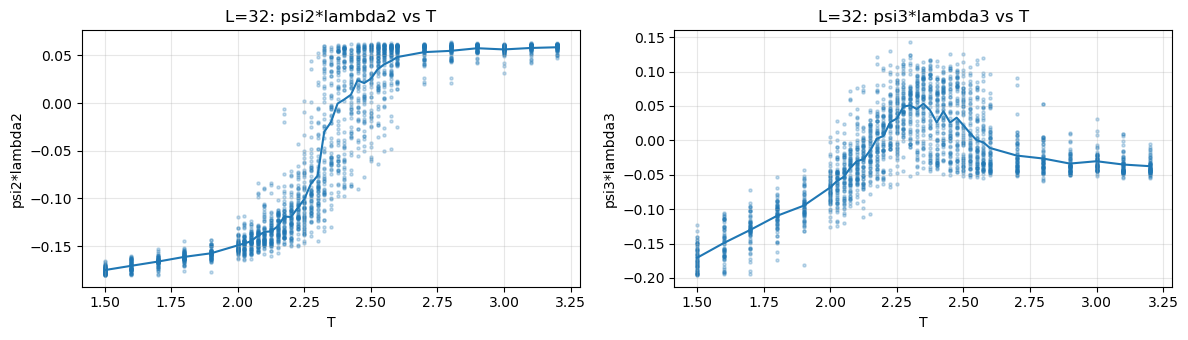

In [77]:
# --- Plot psi2/psi3 vs T ---

def _mean_by_T(T: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    T = np.asarray(T)
    y = np.asarray(y)
    Ts = np.unique(T)
    Ts.sort()
    means = np.array([float(np.mean(y[T == t])) for t in Ts], dtype=float)
    return Ts.astype(float), means


for L, res in ising_unsup.items():
    psi = res.get('psi')
    evals = np.asarray(res.get('evals')).reshape(-1)
    T_all = np.asarray(res.get('T_all'))
    if psi is None or evals.size < 3:
        raise ValueError('Need at least 3 diffusion-map eigenvectors; re-run the unsupervised cell with DM_N_EIGS>=3.')

    psi2 = psi[:, 1] * float(evals[1])
    psi3 = psi[:, 2] * float(evals[2])

    t2, m2 = _mean_by_T(T_all, psi2)
    t3, m3 = _mean_by_T(T_all, psi3)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharex=True)
    axes[0].scatter(T_all, psi2, s=5, alpha=0.25)
    axes[0].plot(t2, m2, lw=1.5)
    axes[0].set_title(f'L={L}: psi2*lambda2 vs T')
    axes[0].set_xlabel('T')
    axes[0].set_ylabel('psi2*lambda2')
    axes[0].grid(True, alpha=0.3)

    axes[1].scatter(T_all, psi3, s=5, alpha=0.25)
    axes[1].plot(t3, m3, lw=1.5)
    axes[1].set_title(f'L={L}: psi3*lambda3 vs T')
    axes[1].set_xlabel('T')
    axes[1].set_ylabel('psi3*lambda3')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


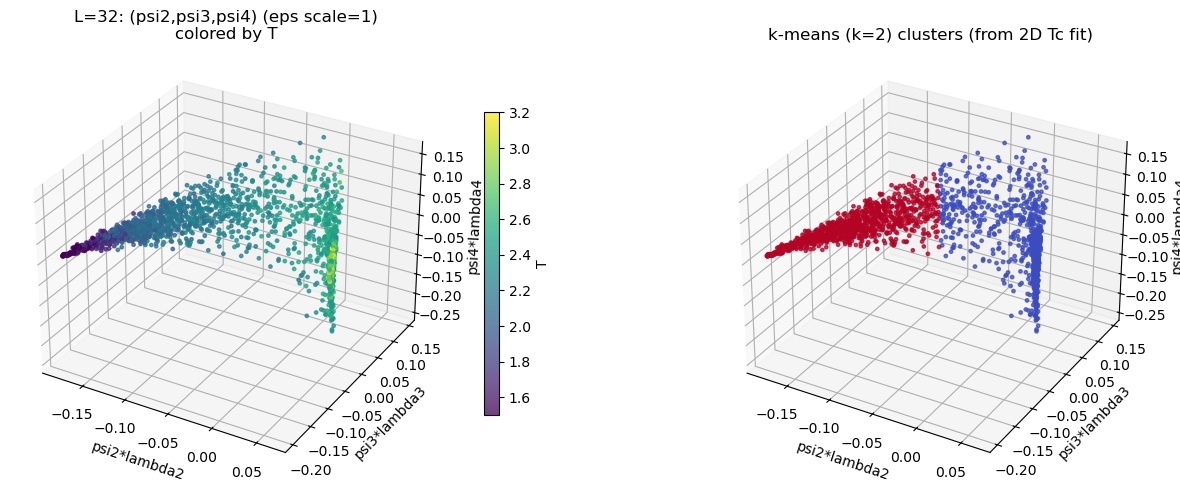

In [78]:
# --- 3D embedding (psi2, psi3, psi4) using the same DM epsilon/kNN ---
# NOTE: the diffusion embedding is only defined up to sign/rotation and k-means can change if you
# cluster in a different dimensional subspace. By default we *reuse* the k=2 labels computed in
# the main unsupervised cell (which clusters in the same 2D space used for Tc extraction).

CLUSTER_IN_3D = False  # set True to re-run k-means in 3D (psi2,psi3,psi4)

for L, res in ising_unsup.items():
    psi = res.get('psi', None)
    evals = np.asarray(res.get('evals', None)).reshape(-1)
    T_all = np.asarray(res.get('T_all', None))
    eps_scale = res.get('epsilon_scale', None)

    if psi is None or evals.size < 4 or psi.shape[1] < 4:
        raise ValueError('Need at least 4 eigenvectors (psi1..psi4) to plot (psi2,psi3,psi4). Set DM_N_EIGS>=4 and re-run the unsupervised cell.')

    Y3 = psi[:, 1:4] * evals[1:4]

    if CLUSTER_IN_3D:
        labels, _centers, _inertia = kmeans_numpy(
            Y3,
            k=2,
            rng=np.random.default_rng(321 + int(L)),
            n_init=30,
            max_iter=400,
        )

        # Orient labels using temperature (ordered phase dominates at the lowest T)
        lowT = float(np.min(res['temps']))
        mask_low = np.isclose(T_all, lowT)
        f0_low = float(np.mean(labels[mask_low] == 0)) if np.any(mask_low) else float('nan')
        f1_low = float(np.mean(labels[mask_low] == 1)) if np.any(mask_low) else float('nan')
        ordered_cluster = 0 if f0_low >= f1_low else 1
        ordered = labels == ordered_cluster
        cluster_title = 'k-means (k=2) clusters (3D)'
    else:
        # Reuse labels from the main unsupervised cell (computed per-L on pooled data).
        ordered = np.asarray(res['ordered'], dtype=bool)
        cluster_title = 'k-means (k=2) clusters (from 2D Tc fit)'

    title_eps = f" (eps scale={eps_scale:g})" if eps_scale is not None else ""

    fig = plt.figure(figsize=(16, 5))
    ax0 = fig.add_subplot(1, 2, 1, projection='3d')
    p0 = ax0.scatter(Y3[:, 0], Y3[:, 1], Y3[:, 2], c=T_all, s=6, alpha=0.75, cmap='viridis')
    ax0.set_title(f"L={L}: (psi2,psi3,psi4){title_eps}\ncolored by T")
    ax0.set_xlabel('psi2*lambda2')
    ax0.set_ylabel('psi3*lambda3')
    ax0.set_zlabel('psi4*lambda4')
    fig.colorbar(p0, ax=ax0, shrink=0.7, pad=0.05, label='T')

    ax1 = fig.add_subplot(1, 2, 2, projection='3d')
    ax1.scatter(Y3[:, 0], Y3[:, 1], Y3[:, 2], c=ordered.astype(int), s=6, alpha=0.75, cmap='coolwarm')
    ax1.set_title(cluster_title)
    ax1.set_xlabel('psi2*lambda2')
    ax1.set_ylabel('psi3*lambda3')
    ax1.set_zlabel('psi4*lambda4')

    plt.tight_layout()
    plt.show()


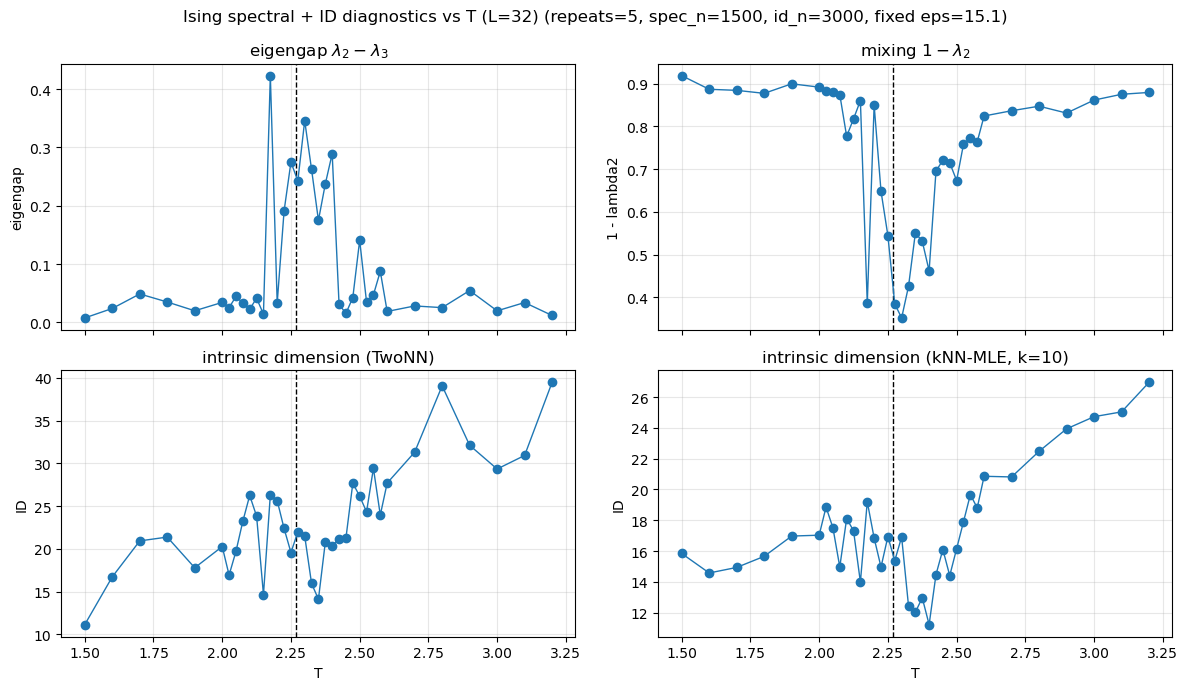

In [79]:
# --- Spectral + intrinsic-dimension diagnostics vs T (classical transitions) ---

SPEC_N_EIGS = 6
N_REPEATS = 5  # average over random subsamples to reduce noise
SPEC_MAX_SAMPLES_PER_T = 1500
ID_MAX_SAMPLES_PER_T = 3000
ID_K_MLE = 10


def _subsample(X: np.ndarray, n_max: int, rng: np.random.Generator) -> np.ndarray:
    n = int(X.shape[0])
    if n <= int(n_max):
        return X
    idx = rng.choice(n, size=int(n_max), replace=False)
    return X[idx]


def diagnostics_vs_T(
    ds: Dataset,
    rng: np.random.Generator,
    epsilon_fixed: float | None = None,
) -> dict[str, np.ndarray]:
    temps = np.asarray(ds.temps, dtype=float)
    n_t = int(ds.X.shape[0])
    lam2 = np.full(n_t, np.nan, dtype=float)
    lam3 = np.full(n_t, np.nan, dtype=float)
    gap23 = np.full(n_t, np.nan, dtype=float)
    mix = np.full(n_t, np.nan, dtype=float)  # 1 - lambda2
    id_twonn = np.full(n_t, np.nan, dtype=float)
    id_knn = np.full(n_t, np.nan, dtype=float)
    lam2_std = np.full(n_t, np.nan, dtype=float)
    lam3_std = np.full(n_t, np.nan, dtype=float)
    gap23_std = np.full(n_t, np.nan, dtype=float)
    mix_std = np.full(n_t, np.nan, dtype=float)
    id_twonn_std = np.full(n_t, np.nan, dtype=float)
    id_knn_std = np.full(n_t, np.nan, dtype=float)

    for ti in range(n_t):
        X_T = np.asarray(ds.X[ti]).reshape(int(ds.X.shape[1]), -1)

        # Stabilize epsilon per temperature: choose once (then reuse across repeats).
        eps_ref = None
        if epsilon_fixed is not None:
            eps_ref = float(epsilon_fixed)
        else:
            X_eps = _subsample(X_T, max(int(SPEC_MAX_SAMPLES_PER_T), int(DM_KNN) + 2), rng)
            if X_eps.shape[0] >= 3:
                idx_eps, d2_eps = knn_graph(X_eps, k=int(DM_KNN))
                vals = d2_eps[d2_eps > 0]
                eps0 = float(np.median(vals)) if vals.size else 1.0
                eps_ref = eps0 if eps0 > 0 else 1.0

        lam2_r = []
        lam3_r = []
        gap23_r = []
        mix_r = []
        id2_r = []
        idk_r = []

        for _rep in range(int(N_REPEATS)):
            # Spectral on a (possibly) large subsample.
            X_spec = _subsample(X_T, SPEC_MAX_SAMPLES_PER_T, rng)
            if X_spec.shape[0] >= 3 and eps_ref is not None:
                idx_knn, d2 = knn_graph(X_spec, k=int(DM_KNN))
                evals, _psi = diffusion_map_eigs_from_knn_graph(
                    idx_knn,
                    d2,
                    n_eigs=int(SPEC_N_EIGS),
                    alpha=float(DM_ALPHA),
                    epsilon=float(eps_ref),
                )
                if evals.size > 1:
                    lam2_r.append(float(evals[1]))
                    mix_r.append(float(1.0 - evals[1]))
                if evals.size > 2:
                    lam3_r.append(float(evals[2]))
                    gap23_r.append(float(evals[1] - evals[2]))

            # ID on a (possibly) larger subsample.
            X_id = _subsample(X_T, ID_MAX_SAMPLES_PER_T, rng)
            if X_id.shape[0] >= 3:
                try:
                    id2_r.append(float(intrinsic_dim_two_nn(X_id)))
                except Exception:
                    pass
            if X_id.shape[0] >= (int(ID_K_MLE) + 2):
                try:
                    idk_r.append(float(intrinsic_dim_knn_mle(X_id, k=int(ID_K_MLE))))
                except Exception:
                    pass

        def _mean_std(vals: list[float]) -> tuple[float, float]:
            if not vals:
                return float('nan'), float('nan')
            a = np.asarray(vals, dtype=float)
            a = a[np.isfinite(a)]
            if a.size == 0:
                return float('nan'), float('nan')
            return float(np.mean(a)), float(np.std(a, ddof=0))

        lam2[ti], lam2_std[ti] = _mean_std(lam2_r)
        lam3[ti], lam3_std[ti] = _mean_std(lam3_r)
        gap23[ti], gap23_std[ti] = _mean_std(gap23_r)
        mix[ti], mix_std[ti] = _mean_std(mix_r)
        id_twonn[ti], id_twonn_std[ti] = _mean_std(id2_r)
        id_knn[ti], id_knn_std[ti] = _mean_std(idk_r)

    return {
        'temps': temps,
        'lambda2': lam2,
        'lambda2_std': lam2_std,
        'lambda3': lam3,
        'lambda3_std': lam3_std,
        'eigengap_23': gap23,
        'eigengap_23_std': gap23_std,
        'mixing_1m2': mix,
        'mixing_1m2_std': mix_std,
        'id_twonn': id_twonn,
        'id_twonn_std': id_twonn_std,
        'id_knn_mle': id_knn,
        'id_knn_mle_std': id_knn_std,
    }


def _plot_diag(diag: dict[str, np.ndarray], title: str, Tc: float | None = None) -> None:
    T = diag['temps']
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
    axes = axes.ravel()

    axes[0].errorbar(T, diag['eigengap_23'], yerr=diag.get('eigengap_23_std', None), marker='o', lw=1, capsize=2)
    axes[0].set_title(r'eigengap $\lambda_2-\lambda_3$')
    axes[0].set_ylabel('eigengap')

    axes[1].errorbar(T, diag['mixing_1m2'], yerr=diag.get('mixing_1m2_std', None), marker='o', lw=1, capsize=2)
    axes[1].set_title(r'mixing $1-\lambda_2$')
    axes[1].set_ylabel('1 - lambda2')

    axes[2].errorbar(T, diag['id_twonn'], yerr=diag.get('id_twonn_std', None), marker='o', lw=1, capsize=2)
    axes[2].set_title('intrinsic dimension (TwoNN)')
    axes[2].set_xlabel('T')
    axes[2].set_ylabel('ID')

    axes[3].errorbar(T, diag['id_knn_mle'], yerr=diag.get('id_knn_mle_std', None), marker='o', lw=1, capsize=2)
    axes[3].set_title(f'intrinsic dimension (kNN-MLE, k={int(ID_K_MLE)})')
    axes[3].set_xlabel('T')
    axes[3].set_ylabel('ID')

    for ax in axes:
        ax.grid(True, alpha=0.3)
        if Tc is not None and np.isfinite(Tc):
            ax.axvline(float(Tc), color='k', ls='--', lw=1)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


KNOWN_TC_ISING = 2.269185314
# Ising
for L, ds in ising_results.items():
    eps_fixed = None
    try:
        eps_fixed = float(ising_unsup.get(L, {}).get('epsilon')) if 'ising_unsup' in globals() and L in ising_unsup else None
    except Exception:
        eps_fixed = None
    diag = diagnostics_vs_T(ds, rng=np.random.default_rng(700 + int(L)), epsilon_fixed=eps_fixed)
    extra = (
        f" (repeats={int(N_REPEATS)}, spec_n={int(SPEC_MAX_SAMPLES_PER_T)}, id_n={int(ID_MAX_SAMPLES_PER_T)}" +
        (f", fixed eps={eps_fixed:.3g}" if eps_fixed is not None else ", eps=median knn") +
        ")"
    )
    _plot_diag(diag, title=f'Ising spectral + ID diagnostics vs T (L={L}){extra}', Tc=KNOWN_TC_ISING)





L=64: Tc50=2.2837, Tc_slope=2.2800
L=100: Tc50=2.3006, Tc_slope=2.3000
L=200: Tc50=2.2865, Tc_slope=2.2800


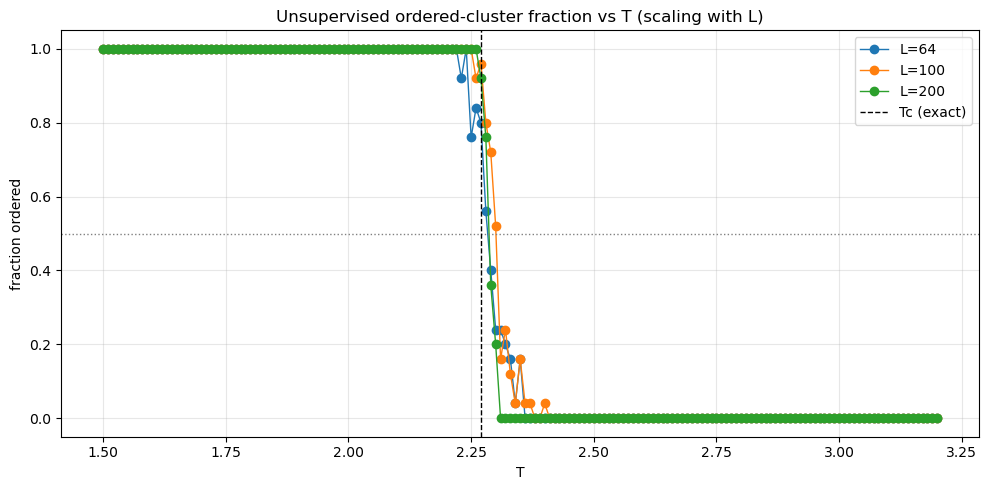

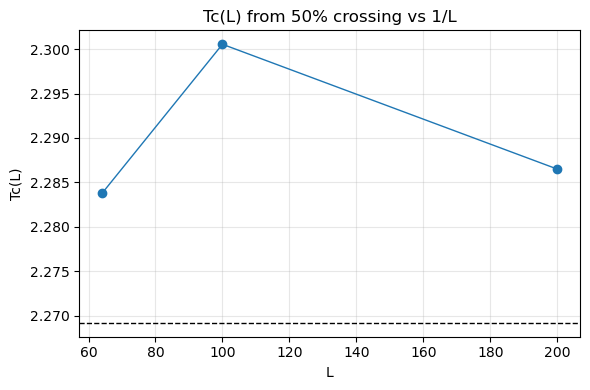

In [80]:
# --- FINAL: scaling-style curve from C++ ensembles (L=64/100/200) ---
# Plots the unsupervised ordered-cluster fraction vs T for each lattice size and a Tc(L) drift plot.
# Requires: `ising_configs_L64.bin`, `ising_configs_L100.bin`, `ising_configs_L200.bin` in `ISING_DIR`.

L_LIST = [64, 100, 200]
BLOCK_SCALING = 4
PER_T_FOR_DM = 25  # stratified subsample per temperature (keeps runtime manageable)
DM_KNN_SCALING = 50
DM_ALPHA_SCALING = 1.0
DM_N_EIGS_SCALING = 6
EPS_SCALE_SCALING = 0.5  # epsilon = eps0 * scale, eps0 = median knn d^2

from pathlib import Path
_available_L = []
_missing = []
for _L in L_LIST:
    _p = Path(ISING_DIR) / f"ising_configs_L{_L}.bin"
    if _p.exists():
        _available_L.append(int(_L))
    else:
        _missing.append(str(_p))
if _missing:
    print("Missing config files (skipping):")
    for _p in _missing:
        print(" -", _p)
L_LIST = _available_L
if not L_LIST:
    raise FileNotFoundError("No `ising_configs_L*.bin` found in ISING_DIR; run the ising.cpp generator first.")


def _flatten_X(ds: Dataset) -> tuple[np.ndarray, np.ndarray]:
    n_t = int(ds.temps.size)
    n_s = int(ds.X.shape[1])
    T = np.repeat(np.asarray(ds.temps, dtype=float), n_s)
    X = np.asarray(ds.X, dtype=np.float32).reshape(n_t * n_s, -1)
    return T, X


def _choose_stratified_indices(n_t: int, n_s: int, per_temp: int, rng: np.random.Generator) -> np.ndarray:
    per_temp = min(int(per_temp), int(n_s))
    blocks = []
    for i in range(int(n_t)):
        block = np.arange(i * n_s, (i + 1) * n_s)
        blocks.append(rng.choice(block, size=per_temp, replace=False))
    return np.concatenate(blocks)


def _crossing_temperature(temps: np.ndarray, values: np.ndarray, target: float = 0.5) -> float:
    temps = np.asarray(temps, dtype=float)
    values = np.asarray(values, dtype=float)
    if temps.size == 0 or values.size == 0:
        return float('nan')
    order = np.argsort(temps)
    temps = temps[order]
    values = values[order]
    y = values - float(target)
    finite = np.isfinite(y)
    if int(np.sum(finite)) < 2:
        return float('nan')
    temps = temps[finite]
    values = values[finite]
    y = values - float(target)
    for i in range(y.size - 1):
        if y[i] == 0.0:
            return float(temps[i])
        if y[i] * y[i + 1] < 0.0:
            t0, t1 = float(temps[i]), float(temps[i + 1])
            v0, v1 = float(values[i]), float(values[i + 1])
            if v1 == v0:
                return float(0.5 * (t0 + t1))
            return t0 + (target - v0) * (t1 - t0) / (v1 - v0)
    idx = int(np.nanargmin(np.abs(y)))
    return float(temps[idx])


def unsup_order_fraction(ds: Dataset, rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray, float, float]:
    temps = np.asarray(ds.temps, dtype=float)
    n_t = int(ds.temps.size)
    n_s = int(ds.X.shape[1])
    T_all, X_all = _flatten_X(ds)

    idx = _choose_stratified_indices(n_t, n_s, per_temp=PER_T_FOR_DM, rng=rng)
    X = X_all[idx]
    T = T_all[idx]

    idx_knn, d2 = knn_graph(X, k=int(DM_KNN_SCALING))
    vals = d2[d2 > 0]
    eps0 = float(np.median(vals)) if vals.size else 1.0
    eps = float(eps0) * float(EPS_SCALE_SCALING)
    evals, psi = diffusion_map_eigs_from_knn_graph(
        idx_knn,
        d2,
        n_eigs=int(DM_N_EIGS_SCALING),
        alpha=float(DM_ALPHA_SCALING),
        epsilon=eps,
    )
    if psi.shape[1] < 3:
        raise ValueError('Need >=3 eigenvectors for (psi2,psi3); increase DM_N_EIGS_SCALING.')
    Y = psi[:, 1:3] * evals[1:3]

    labels, _centers, _inertia = kmeans_numpy(
        Y,
        k=2,
        rng=np.random.default_rng(123),
        n_init=20,
        max_iter=300,
    )

    lowT = float(np.min(temps))
    mask_low = np.isclose(T, lowT)
    f0_low = float(np.mean(labels[mask_low] == 0)) if np.any(mask_low) else float('nan')
    f1_low = float(np.mean(labels[mask_low] == 1)) if np.any(mask_low) else float('nan')
    ordered_cluster = 0 if f0_low >= f1_low else 1
    ordered = labels == ordered_cluster

    frac = np.array([float(np.mean(ordered[np.isclose(T, float(t))])) for t in temps], dtype=float)
    tc50 = _crossing_temperature(temps, frac, target=0.5)
    slope = np.gradient(frac, temps)
    tcslope = float(temps[int(np.nanargmax(np.abs(slope)))]) if np.any(np.isfinite(slope)) else float('nan')
    return temps, frac, tc50, tcslope


scaling = {}
for L in L_LIST:
    path = ISING_DIR / f'ising_configs_L{int(L)}.bin'
    if not path.exists():
        print('Missing:', path)
        continue
    dsL = load_ising_configs_bin(path, block=int(BLOCK_SCALING))
    temps, frac, tc50, tcslope = unsup_order_fraction(dsL, rng=np.random.default_rng(1000 + int(L)))
    scaling[int(L)] = {'temps': temps, 'frac': frac, 'tc50': tc50, 'tcslope': tcslope}
    print(f'L={int(L)}: Tc50={tc50:.4f}, Tc_slope={tcslope:.4f}')

if not scaling:
    raise FileNotFoundError('No C++ config files found; generate `ising_configs_L*.bin` first.')

plt.figure(figsize=(10, 5))
for L in sorted(scaling):
    d = scaling[L]
    plt.plot(d['temps'], d['frac'], marker='o', lw=1, label=f'L={L}')
plt.axhline(0.5, color='gray', ls=':', lw=1)
plt.axvline(2.269185314, color='k', ls='--', lw=1, label='Tc (exact)')
plt.title('Unsupervised ordered-cluster fraction vs T (scaling with L)')
plt.xlabel('T')
plt.ylabel('fraction ordered')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

Ls = np.array(sorted(scaling), dtype=float)
tc = np.array([scaling[int(L)]['tc50'] for L in Ls], dtype=float)
plt.figure(figsize=(6, 4))
plt.plot(Ls, tc, marker='o', lw=1)
plt.axhline(2.269185314, color='k', ls='--', lw=1)
plt.title('Tc(L) from 50% crossing vs 1/L')
plt.xlabel('L')
plt.ylabel('Tc(L)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
